<a href="https://colab.research.google.com/github/kangtayie/Machine-Learning_class/blob/main/wine_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 와인 분류(DT, RF, LR, KNN)

In [1]:
# 임포트
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
# 분류용 모델 (DT, RF, LR, KNN)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [3]:
# 데이터 불러오기
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wine.csv")
df.head()   # 데이터 앞부분 확인 (맨 앞 Wine이 정답 클래스)

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
# 데이터/레이블 분리(Wine = 분류 레이블)
X = df.drop("Wine", axis=1)
y = df["Wine"]

In [5]:
# random_state 고정 → 4개 모델 동일 조건 비교 / stratify → 클래스 비율 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# 모델 생성 → 훈련(fit) → 예측(predict) → 평가(classification_report)
clf_models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=5000),  # 스케일 차이 커서 반복 넉넉히
    "KNN": KNeighborsClassifier(),
}

for name, model in clf_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, pred))

--- DecisionTree ---
              precision    recall  f1-score   support

           1       1.00      0.92      0.96        12
           2       0.88      1.00      0.93        14
           3       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36

--- RandomForest ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

--- LogisticRegression ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.88      1.00      0.93        14
      

# 클래스별 분포 시각화

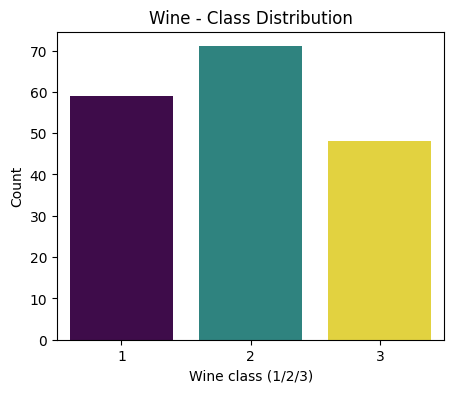

Wine
2    71
1    59
3    48
Name: count, dtype: int64


In [7]:
# 클래스별 분포 시각화 — 세 품종(1/2/3)에 데이터가 몇 개씩 있는지 확인
plt.figure(figsize=(5, 4))
sns.countplot(x="Wine", data=df, hue="Wine", palette="viridis", legend=False)
plt.title("Wine - Class Distribution")
plt.xlabel("Wine class (1/2/3)")
plt.ylabel("Count")
plt.show()

print(df["Wine"].value_counts())   # 클래스별 개수 숫자로도 확인